In [1]:
#Libreria SDV
import pandas as pd
import numpy as np
import random

In [2]:
import sdv
import sdmetrics

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [3]:
from sdmetrics.reports.single_table import QualityReport

In [4]:
print("SDV: ", sdv.__version__)

SDV:  1.37.0


In [5]:
#Creamos un dataset (original) que sirva como fuente para crear los datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [23,33,43,28,53,56,43,56,65,40],
        "ingreso_mensual" : [25000,15000,20000,10000,5000,17000,30000,12000,35000,7500],
        "ciudad" : ["Veracruz", "Cordoba", "Paso del Macho", "Amatlan", "Fortin de las Flores", "Cuitlahuac", "Tezonapa", "Yanga", "Orizaba", "Cuitlahuac"]
    }
)

In [6]:
dfClientes.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,25000,Veracruz
1,2,33,15000,Cordoba
2,3,43,20000,Paso del Macho
3,4,28,10000,Amatlan
4,5,53,5000,Fortin de las Flores


In [7]:
#Definr los metadatos
metadata = SingleTableMetadata()

In [8]:
metadata.detect_from_dataframe(
    data  = dfClientes
)

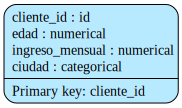

In [9]:
#instalar graphviz
metadata.visualize()

In [10]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'primary_key': 'cliente_id'}

In [11]:
#Guardamos el netadata en un archivo JSON
metadata.save_to_json(
    "dfClientes_metadata.json"
)

In [12]:
# Entrenamos el modelo para generar los daot sinteticos 
synthetizer = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\abiel\anaconda3\envs\Extraccioin9B\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [13]:
#Entrenamiento
synthetizer.fit(
    dfClientes
)

In [14]:
#Generamos los datos sinteticos
clientes_fake = synthetizer.sample (
    num_rows=100
)

In [15]:
clientes_fake.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,62,24302,Yanga
1,4918803,33,29436,Cuitlahuac
2,1900081,40,17384,Cuitlahuac
3,531516,30,19313,Cuitlahuac
4,10211768,49,29975,Yanga


In [16]:
clientes_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       100 non-null    int64 
 1   edad             100 non-null    int64 
 2   ingreso_mensual  100 non-null    int64 
 3   ciudad           100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [17]:
clientes_fake.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.000000e+02,100.000000,100.000000,100
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,Cuitlahuac
freq,NaN,NaN,NaN,23
mean,8.532170e+06,43.130000,21700.900000,NaN
std,4.687773e+06,12.190951,8937.168314,NaN
min,4.660500e+04,28.000000,6124.000000,NaN
25%,5.008268e+06,31.000000,13603.250000,NaN
50%,8.656048e+06,40.500000,22667.000000,NaN
75%,1.256688e+07,54.000000,29693.750000,NaN


In [18]:
#Dtaset contaminado
dfClientesGIGO = clientes_fake.copy()

In [19]:
#colocar edades  imposibles
indices = random.sample(list(dfClientesGIGO.index),5)

In [20]:
dfClientesGIGO.loc[indices, "edad"] = -5

In [21]:
#Introducimos valores duplicados}
duplicados = dfClientesGIGO.sample(10,random_state=42)

In [22]:
dfClientesGIGO = pd.concat([dfClientesGIGO, duplicados], ignore_index= True)

In [23]:
#Verificamos valores nulos
dfClientesGIGO.duplicated().sum()

np.int64(10)

In [24]:
dfClientesGIGO.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,Cordoba
freq,NaN,NaN,NaN,28
mean,8.614045e+06,39.972727,21087.945455,NaN
std,4.775996e+06,15.489244,9104.529809,NaN
min,4.660500e+04,-5.000000,6124.000000,NaN
25%,4.948624e+06,30.000000,13281.750000,NaN
50%,8.956428e+06,38.000000,21969.500000,NaN
75%,1.274153e+07,53.000000,29499.000000,NaN


In [25]:
#Generamos reporte
reporte = QualityReport()

In [26]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = clientes_fake,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 500.07it/s]|
Column Shapes Score: 78.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 55.66it/s]|
Column Pair Trends Score: 14.0%

Overall Score (Average): 46.0%



In [27]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = clientes_fake,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 665.76it/s]|
Column Shapes Score: 78.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 260.62it/s]|
Column Pair Trends Score: 14.0%

Overall Score (Average): 46.0%

